# Exercício 02 — Atendimento 360

**Empresa simulada:** central de suporte com **histórico completo** — o cliente muda de ideia e espera continuidade («reunião de segunda-feira»).

Este notebook cobre:

1. **Memória de conversa** com LangChain + Gemini (exemplo *João*).
2. **Várias conversas simuladas** (JSON em `app/data/generated/`).
3. **Extração estruturada** com **Pydantic** + `with_structured_output` (cadeia tipo *agente* analista).
4. **Relatórios** Markdown/JSON agregados sobre o lote.
5. **DataFrame** (Pandas) a partir das extrações + **gráficos consolidados** e **projeções** ilustrativas de volume por urgência.

Documentação: `docs/memoria_conversa.md`, `README.md`.


## 0. Ambiente e caminhos

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv

EX_ROOT = Path.cwd().resolve()
REPO_ROOT = EX_ROOT.parent.parent

load_dotenv(REPO_ROOT / ".env", override=False)
load_dotenv(EX_ROOT / ".env", override=True)

if not (os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")):
    raise RuntimeError("Defina GOOGLE_API_KEY no .env na raiz do repositório.")

OUT_GEN = EX_ROOT / "app/data/generated"
OUT_GEN.mkdir(parents=True, exist_ok=True)

print("OK — Repo:", REPO_ROOT)
print("OK — Exercício:", EX_ROOT)
print("OK — Artefactos:", OUT_GEN)


OK — Repo: /home/jovyan/work/repo
OK — Exercício: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360
OK — Artefactos: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated


## 1. Loop de conversa com histórico

In [2]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
import json
import os
from pathlib import Path

SYSTEM = (
    "És um assistente da empresa Atendimento 360. "
    "Respondes em português europeu, com cordialidade. Usa todo o histórico desta conversa."
)

def montar_mensagens(hist: list[dict]) -> list:
    out = [SystemMessage(content=SYSTEM)]
    for m in hist:
        if m["role"] == "user":
            out.append(HumanMessage(content=m["content"]))
        else:
            out.append(AIMessage(content=m["content"]))
    return out

def turno(hist: list[dict], texto: str) -> list[dict]:
    hist = [*hist, {"role": "user", "content": texto}]
    llm = ChatGoogleGenerativeAI(
        model=(os.environ.get("GEMINI_MODEL") or "gemini-2.0-flash").replace("models/", ""),
        temperature=0.35,
    )
    ai: AIMessage = llm.invoke(montar_mensagens(hist))
    reply = ai.content if isinstance(ai.content, str) else str(ai.content)
    return [*hist, {"role": "assistant", "content": reply}]

h: list[dict] = []
h = turno(h, "O meu nome é João.")
h = turno(h, "Qual é o meu nome?")
print(json.dumps(h, ensure_ascii=False, indent=2))

p_demo = OUT_GEN / "historico_demo_joao.json"
p_demo.write_text(json.dumps(h, ensure_ascii=False, indent=2), encoding="utf-8")
Path("historico_export.json").write_text(json.dumps(h, ensure_ascii=False, indent=2), encoding="utf-8")
print("Exportado:", p_demo, "e historico_export.json")


[
  {
    "role": "user",
    "content": "O meu nome é João."
  },
  {
    "role": "assistant",
    "content": "Olá João, tudo bem? Em que posso ajudar hoje?"
  },
  {
    "role": "user",
    "content": "Qual é o meu nome?"
  },
  {
    "role": "assistant",
    "content": "O seu nome é João. 😊 Em que posso ajudar hoje, João?"
  }
]
Exportado: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/historico_demo_joao.json e historico_export.json


## 2. Gerar várias conversas simuladas

Roteiros **determinísticos** (sem custo de tokens) que imitam tickets reais: faturação, mudança de ideia, IoT, escalonamento e morada. Gravamos o lote em `app/data/generated/conversas_simuladas.json`.

In [3]:
import json

CONVERSAS_SIMULADAS: list[dict] = [
    {
        "id": "C001_fatura",
        "titulo": "Fatura duplicada",
        "turnos": [
            {"role": "user", "content": "Boa tarde, sou a Ana Silva. A fatura de abril apareceu duplicada no débito direto."},
            {"role": "assistant", "content": "Olá Ana, peço desculpa pelo incómodo. Confirma o NIF da conta e os últimos quatro dígitos do IBAN?"},
            {"role": "user", "content": "NIF 209123456, IBAN ...9921. Quero o reembolso da segunda cobrança até sexta-feira."},
            {"role": "assistant", "content": "Obrigado pelos dados. Vou abrir um pedido de estorno da linha duplicada com prioridade e envio o número do caso por email."},
        ],
    },
    {
        "id": "C002_muda_ideia",
        "titulo": "Cancelamento vs downgrade",
        "turnos": [
            {"role": "user", "content": "Sou o Carlos. Quero cancelar o plano Business já."},
            {"role": "assistant", "content": "Carlos, posso ajudar com o cancelamento. O motivo foi preço ou funcionalidades?"},
            {"role": "user", "content": "Na verdade espera — não quero cancelar. Quero só baixar para o plano Standard e manter os utilizadores atuais."},
            {"role": "assistant", "content": "Perfeito: fazemos downgrade para Standard mantendo as contas. A renovação passa a mensal com o novo tarifário."},
            {"role": "user", "content": "Ok. Confirma que fico com os mesmos 12 utilizadores e sem período de carência ridículo."},
            {"role": "assistant", "content": "Sim: 12 seats preservados; aplicamos a mudança imediata sem carência adicional no seu caso."},
        ],
    },
    {
        "id": "C003_sensor",
        "titulo": "Sensor offline",
        "turnos": [
            {"role": "user", "content": "Maria aqui. O hub IoT mostra o sensor da sala a cinzento desde ontem."},
            {"role": "assistant", "content": "Maria, já reiniciou o hub pela app? Se sim, qual o código do dispositivo nas definições?"},
            {"role": "user", "content": "Reiniciei. Código DEV-4481. Continua offline."},
            {"role": "assistant", "content": "Obrigado. Vejo uma falha de firmware conhecida — agendo push OTA forçado nas próximas 2 h e aviso por SMS."},
        ],
    },
    {
        "id": "C004_espera",
        "titulo": "Reclamação de espera",
        "turnos": [
            {"role": "user", "content": "Sofia Costa. Estive 40 minutos na linha. Inaceitável."},
            {"role": "assistant", "content": "Sofia, lamento sinceramente a espera. Em que posso resolver já?"},
            {"role": "user", "content": "Preciso de escalonar um incidente crítico no data center de Lisboa. SLA está em risco."},
            {"role": "assistant", "content": "Abro ticket P1 com bridge ao NOC e envio-lhe o ID em seguida com atualizações a cada 30 minutos."},
        ],
    },
    {
        "id": "C005_billing",
        "titulo": "Morada de faturação",
        "turnos": [
            {"role": "user", "content": "Olá, sou o Pedro. Mudámos de sede — a fatura ainda vai para a morada antiga em Porto."},
            {"role": "assistant", "content": "Pedro, indique o novo endereço completo e o Código de Cliente na área reservada."},
            {"role": "user", "content": "Cliente CL-88902. Nova morada: Rua das Indústrias 15, 4000-222 Porto."},
            {"role": "assistant", "content": "Atualizado para CL-88902; a próxima fatura já sai com a morada nova."},
        ],
    },
]

path_lote = OUT_GEN / "conversas_simuladas.json"
path_lote.write_text(json.dumps(CONVERSAS_SIMULADAS, ensure_ascii=False, indent=2), encoding="utf-8")
print(len(CONVERSAS_SIMULADAS), "conversas →", path_lote)

5 conversas → /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/conversas_simuladas.json


## 3. Modelos Pydantic (dados estruturados)

Definimos o que queremos **extrair** de cada conversa e o formato do **relatório agregado** sobre o lote.

In [4]:
from typing import Literal

from pydantic import BaseModel, Field


class ExtracaoConversa(BaseModel):
    """Dados estruturados extraídos de uma conversa de suporte."""

    conversa_id: str = Field(description="Identificador fornecido no pedido (ex.: C001_fatura)")
    nome_cliente: str | None = Field(description="Nome próprio identificável do cliente, se existir")
    sentimento_global: Literal["positivo", "neutro", "negativo", "misto"]
    motivo_contacto: str = Field(description="Frase curta com o motivo principal")
    produto_ou_servico: str | None = Field(description="Produto, plano ou serviço mencionado")
    pedido_principal: str = Field(description="O que o cliente pede explicitamente")
    urgencia: Literal["baixa", "media", "alta"]
    entidades: dict[str, str] = Field(
        default_factory=dict,
        description="Pares chave/valor (ex.: nif, codigo_cliente, dispositivo)",
    )
    insights_supervisor: list[str] = Field(description="Bullets accionáveis para supervisão")
    risco_churn: Literal["baixo", "medio", "alto"] | None = None


class RelatorioAgregado(BaseModel):
    """Síntese sobre um lote de conversas já extraídas."""

    total_conversas: int
    resumo_executivo: str
    por_urgencia: dict[str, int]
    temas_principais: list[str]
    recomendacoes_operacao: list[str]


## 4. «Agente» analista — extração com LangChain + Gemini

Usamos `ChatGoogleGenerativeAI.with_structured_output(ExtracaoConversa)`: não é um agente com ferramentas, mas uma **cadeia** que obriga o modelo a devolver JSON válido conforme o schema Pydantic — padrão típico em pipelines de **analytics sobre tickets**.

In [5]:
SYS_ANALISTA = (
    "És analista de qualidade numa central Atendimento 360. "
    "Extrai apenas informação sustentada no texto; usa null ou dicionários vazios quando não existir."
)


def conversa_para_texto(conv: dict) -> str:
    linhas = [f"[{conv['id']}] {conv.get('titulo', '')}"]
    for m in conv["turnos"]:
        quem = "Cliente" if m["role"] == "user" else "Assistente"
        linhas.append(f"{quem}: {m['content']}")
    return "\n".join(linhas)


llm_base = ChatGoogleGenerativeAI(
    model=(os.environ.get("GEMINI_MODEL") or "gemini-2.0-flash").replace("models/", ""),
    temperature=0.1,
)
extrator = llm_base.with_structured_output(ExtracaoConversa)

rel_dir = OUT_GEN / "relatorios"
rel_dir.mkdir(parents=True, exist_ok=True)

extracoes: list[ExtracaoConversa] = []
for conv in CONVERSAS_SIMULADAS:
    txt = conversa_para_texto(conv)
    msg_user = HumanMessage(
        content=(
            "Extrai o schema para esta conversa. "
            f"conversa_id deve ser exatamente: {conv['id']}\n\n" + txt
        )
    )
    out: ExtracaoConversa = extrator.invoke([SystemMessage(content=SYS_ANALISTA), msg_user])
    extracoes.append(out)
    p_one = rel_dir / f"extracao_{conv['id']}.json"
    p_one.write_text(out.model_dump_json(indent=2, ensure_ascii=False), encoding="utf-8")

print("Extrações gravadas em", rel_dir)
for e in extracoes:
    print("-", e.conversa_id, e.urgencia, e.sentimento_global)

Extrações gravadas em /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios
- C001_fatura alta negativo
- C002_muda_ideia media neutro
- C003_sensor media negativo
- C004_espera alta negativo
- C005_billing baixa neutro


## 5. Relatório agregado (Markdown + JSON)

Segunda passagem estruturada: resume o **lote** de extrações em `RelatorioAgregado` e grava `RELATORIO_LOTE.md` / `RELATORIO_LOTE.json`.

In [6]:
agregador = llm_base.with_structured_output(RelatorioAgregado)
corpus = "\n\n".join(e.model_dump_json(ensure_ascii=False) for e in extracoes)
rel: RelatorioAgregado = agregador.invoke(
    [
        SystemMessage(
            content="Agrega extratos JSON de conversas de suporte num relatório operacional. "
            "por_urgencia deve contar conversas por nível (baixa/media/alta). "
            "total_conversas deve coincidir com o número de objetos analisados."
        ),
        HumanMessage(content=f"Lote com {len(extracoes)} conversas:\n\n{corpus}"),
    ]
)

md_lines = [
    "# Relatório agregado — Atendimento 360",
    "",
    f"**Total analisado:** {rel.total_conversas}",
    "",
    "## Resumo executivo",
    rel.resumo_executivo,
    "",
    "## Urgência (contagem)",
]
for k, v in sorted(rel.por_urgencia.items()):
    md_lines.append(f"- **{k}:** {v}")
md_lines += ["", "## Temas principais", *[f"- {t}" for t in rel.temas_principais], "", "## Recomendações", *[f"- {r}" for r in rel.recomendacoes_operacao]]

path_md = rel_dir / "RELATORIO_LOTE.md"
path_md.write_text("\n".join(md_lines), encoding="utf-8")
path_agg_json = rel_dir / "RELATORIO_LOTE.json"
path_agg_json.write_text(rel.model_dump_json(indent=2, ensure_ascii=False), encoding="utf-8")
print("Markdown:", path_md)
print("JSON agregado:", path_agg_json)

Markdown: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios/RELATORIO_LOTE.md
JSON agregado: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios/RELATORIO_LOTE.json


## 6. DataFrame Pandas e gráficos consolidados (+ projeções)

Convertemos cada `ExtracaoConversa` numa linha tabular, gravamos **CSV/Parquet** e visualizamos:

- distribuição de **urgência** e **sentimento**;
- **projeção ilustrativa** (cenário: o lote atual representa um período; aplicamos taxa de crescimento semanal constante aos próximos períodos e mantemos a proporção observada entre níveis de urgência).

> As projeções são **pedagógicas**, não previsões estatísticas robustas — servem para ligar dados estruturados do LLM a planeamento operacional.

CSV: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/extracoes_consolidado.csv
Parquet: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/extracoes_consolidado.parquet


,conversa_id,nome_cliente,sentimento_global,urgencia,risco_churn,motivo_contacto,produto_ou_servico,pedido_principal,n_insights,insights_preview,entidades_json
0,C001_fatura,Ana Silva,negativo,alta,medio,Fatura duplicada,fatura,Reembolso da segunda cobrança,3,Verificar a causa da duplicação da fatura | Ga...,"{""nif"": ""209123456"", ""iban_ultimos_digitos"": ""..."
1,C002_muda_ideia,Carlos,neutro,media,baixo,Mudança de plano de Business para Standard,Plano Business,Downgrade para o plano Standard mantendo os 12...,4,"Cliente inicialmente queria cancelar o plano, ...","{""numero_utilizadores"": ""12""}"
2,C003_sensor,Maria,negativo,media,medio,Sensor offline,sensor,Resolver problema do sensor offline,2,Possível falha de firmware a necessitar interv...,"{""codigo_dispositivo"": ""DEV-4481""}"
3,C004_espera,Sofia Costa,negativo,alta,medio,Reclamação de tempo de espera,data center,Escalonar incidente crítico,3,Cliente reporta tempo de espera de 40 minutos....,"{""localizacao"": ""Lisboa""}"
4,C005_billing,Pedro,neutro,baixa,None,Atualização da morada de faturação devido a mu...,None,Atualizar a morada de faturação.,2,Cliente informa novo endereço para faturação. ...,"{""codigo_cliente"": ""CL-88902"", ""nova_morada"": ..."


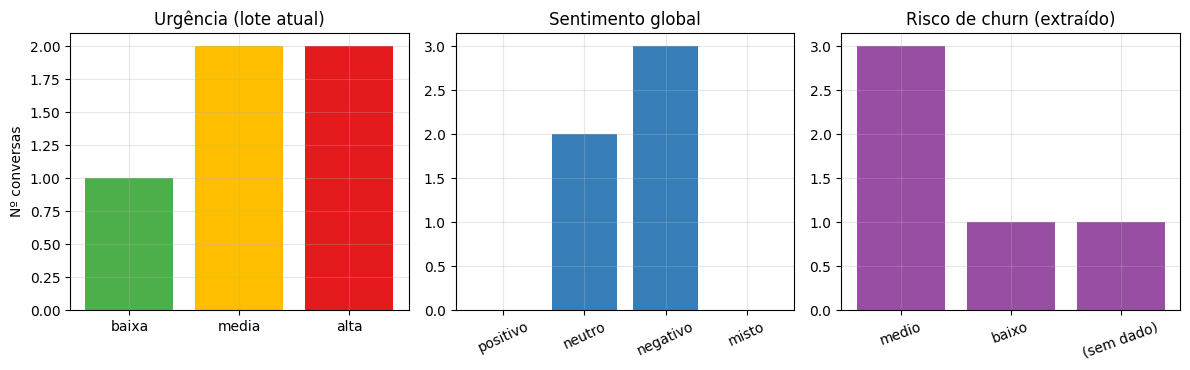

Figura: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios/grafico_consolidado_urgencia_sentimento.png


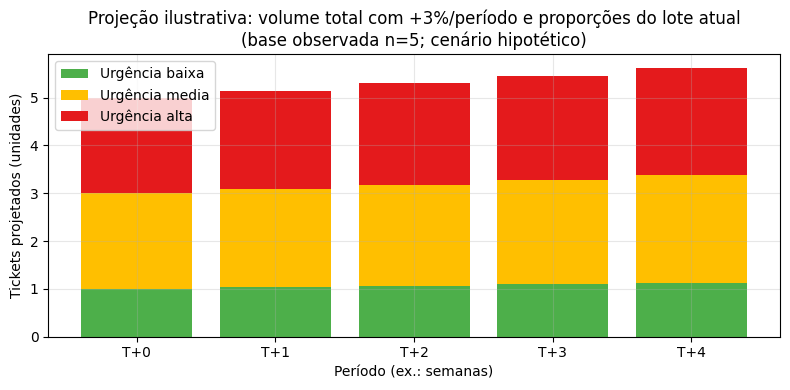

Figura: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios/grafico_projecao_volume_urgencia.png


,periodo,volume_total_proj,proj_baixa,proj_media,proj_alta
0,T+0,5.00,1.000,2.000,2.000
1,T+1,5.15,1.030,2.060,2.060
2,T+2,5.30,1.061,2.122,2.122
3,T+3,5.46,1.093,2.185,2.185
4,T+4,5.63,1.126,2.251,2.251


Projecções CSV: /home/jovyan/work/repo/empresas-automatizadas-ia/exercicio-02-atendimento-360/app/data/generated/relatorios/projecao_volume_urgencia.csv


In [7]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Tabularizar extrações Pydantic (requer células de extração já executadas).
registos: list[dict] = []
for e in extracoes:
    d = e.model_dump()
    insights = d.pop("insights_supervisor", [])
    ent = d.pop("entidades", {})
    registos.append(
        {
            **d,
            "n_insights": len(insights),
            "insights_preview": " | ".join(insights[:4]),
            "entidades_json": json.dumps(ent, ensure_ascii=False),
        }
    )

df_extracoes = pd.DataFrame(registos)
cols_ordem = [
    "conversa_id",
    "nome_cliente",
    "sentimento_global",
    "urgencia",
    "risco_churn",
    "motivo_contacto",
    "produto_ou_servico",
    "pedido_principal",
    "n_insights",
    "insights_preview",
    "entidades_json",
]
df_extracoes = df_extracoes[[c for c in cols_ordem if c in df_extracoes.columns]]

csv_path = OUT_GEN / "extracoes_consolidado.csv"
parquet_path = OUT_GEN / "extracoes_consolidado.parquet"
df_extracoes.to_csv(csv_path, index=False)
try:
    df_extracoes.to_parquet(parquet_path, index=False)
except Exception as ex:
    parquet_path = None
    print("Parquet opcional:", ex)

print("CSV:", csv_path)
if parquet_path:
    print("Parquet:", parquet_path)
display(df_extracoes)

# --- Gráficos consolidados ---
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})
fig1, axes = plt.subplots(1, 3, figsize=(12, 3.8))

urg_order = ["baixa", "media", "alta"]
sent_order = ["positivo", "neutro", "negativo", "misto"]
df_extracoes["urgencia"] = pd.Categorical(df_extracoes["urgencia"], categories=urg_order, ordered=True)

vc_urg = df_extracoes["urgencia"].value_counts().reindex(urg_order).fillna(0)
axes[0].bar(vc_urg.index.astype(str), vc_urg.values, color=["#4daf4a", "#ffbf00", "#e41a1c"])
axes[0].set_title("Urgência (lote atual)")
axes[0].set_ylabel("Nº conversas")

vc_sent = df_extracoes["sentimento_global"].value_counts().reindex(sent_order).fillna(0)
axes[1].bar(range(len(vc_sent)), vc_sent.values, tick_label=[str(x) for x in vc_sent.index], color="#377eb8")
axes[1].set_title("Sentimento global")
axes[1].tick_params(axis="x", rotation=25)

churn_ser = df_extracoes["risco_churn"].fillna("(sem dado)")
vc_churn = churn_ser.value_counts()
axes[2].bar(range(len(vc_churn)), vc_churn.values, tick_label=[str(x) for x in vc_churn.index], color="#984ea3")
axes[2].set_title("Risco de churn (extraído)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig1_path = rel_dir / "grafico_consolidado_urgencia_sentimento.png"
fig1.savefig(fig1_path, dpi=120, bbox_inches="tight")
plt.show()
print("Figura:", fig1_path)

# --- Projeção ilustrativa de volume por urgência ---
prop = df_extracoes["urgencia"].value_counts(normalize=True).reindex(urg_order).fillna(0)
n_obs = len(df_extracoes)
semanas = np.arange(0, 5)
crescimento_semanal = 1.03  # cenário +3% por período (ajustável)
volume_base = max(n_obs, 1)
volumes = volume_base * (crescimento_semanal**semanas)

fig2, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros_like(semanas, dtype=float)
cores = {"baixa": "#4daf4a", "media": "#ffbf00", "alta": "#e41a1c"}
for u in urg_order:
    fatia = volumes * float(prop.get(u, 0))
    ax.bar(semanas, fatia, bottom=bottom, label=f"Urgência {u}", color=cores[u])
    bottom = bottom + fatia

ax.set_xticks(semanas)
ax.set_xticklabels([f"T+{w}" for w in semanas])
ax.set_ylabel("Tickets projetados (unidades)")
ax.set_xlabel("Período (ex.: semanas)")
ax.set_title(
    "Projeção ilustrativa: volume total com +3%/período e proporções do lote atual\n"
    f"(base observada n={n_obs}; cenário hipotético)"
)
ax.legend(loc="upper left")
plt.tight_layout()
fig2_path = rel_dir / "grafico_projecao_volume_urgencia.png"
fig2.savefig(fig2_path, dpi=120, bbox_inches="tight")
plt.show()
print("Figura:", fig2_path)

# Tabela numérica da projeção (para relatório)
proj_rows = []
for w in semanas:
    total_w = volume_base * (crescimento_semanal**w)
    row = {"periodo": f"T+{int(w)}", "volume_total_proj": round(total_w, 2)}
    for u in urg_order:
        row[f"proj_{u}"] = round(total_w * float(prop.get(u, 0)), 3)
    proj_rows.append(row)

df_proj = pd.DataFrame(proj_rows)
display(df_proj)
proj_csv = rel_dir / "projecao_volume_urgencia.csv"
df_proj.to_csv(proj_csv, index=False)
print("Projecções CSV:", proj_csv)

## Referências

- [`docs/memoria_conversa.md`](docs/memoria_conversa.md) — memória de conversa (sessão vs prompt).
- [`README.md`](README.md) — enunciado alinhado, Docker, Streamlit.
- [`app/main.py`](app/main.py) — UI com exportação `.txt` / `.json`.
- Secção **6** — `extracoes_consolidado.csv` / `.parquet`, figuras PNG e `projecao_volume_urgencia.csv` em `app/data/generated/`.
